### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [204]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample
import wget
from tqdm import tqdm
from IPython.display import clear_output

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [205]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cuda device is available


#### 1. Загрузка данных.

In [206]:
# do not change the code in the block below
# __________start of block__________
# !wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
if not os.path.exists('onegin.txt'):   
    wget.download('https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt')
    
with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

In [207]:
len(text)

141888

#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [208]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


In [209]:
print(f'Number of tokens: {len(tokens)}')

Number of tokens: 84


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [ ]:
# do not change the code in the block below
# __________start of block__________
batch_size = 1024
seq_length = 100
start_column = torch.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column
    
    start_index = torch.randint(low=0, high=len(text_encoded) - batch_size*seq_length - 1, size=(1, ))
    data = torch.tensor(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    
    yield torch.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [168]:
next(generate_chunk())

tensor([[83, 61, 45,  ..., 62, 63, 45],
        [83,  1, 56,  ...,  0, 47, 58],
        [83, 53, 57,  ..., 56, 45, 58],
        ...,
        [83, 49, 58,  ..., 66, 59, 63],
        [83, 73,  1,  ..., 73,  5,  0],
        [83, 56, 50,  ..., 47, 45, 58]])

Далее вам предстоит написать код для обучения модели и генерации текста.

In [169]:
class VanillaCharRNN(nn.Module):
    def __init__(self, num_tokens, embedding_dim, rnn_num_units):
        super().__init__()
        self.num_units = rnn_num_units
        self.embedding = nn.Embedding(num_embeddings=num_tokens, embedding_dim=embedding_dim)
        
        self.rnn_update = nn.Linear(embedding_dim + rnn_num_units, rnn_num_units)
        
        self.rnn_to_logits = nn.Linear(rnn_num_units, num_tokens)
        
    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        
        x_and_h = torch.cat([x_emb, h_prev], dim=-1)
        h_next = self.rnn_update(x_and_h)
        
        h_next = torch.tanh(h_next)
        
        logits = self.rnn_to_logits(h_next) #torch.tanh(self.rnn_to_logits(h_next))
        # logits = torch.tanh(self.rnn_to_logits(h_next))
        
        return h_next, logits
    
    @property
    def device(self):
        return next(self.parameters()).device
    
    def init_hidden_state(self, batch_size):
        return torch.zeros(batch_size, self.num_units, requires_grad=True, device=self.device)
        

In [170]:
model = VanillaCharRNN(num_tokens=len(tokens), embedding_dim=16, rnn_num_units=64)

In [171]:
def rnn_loop(char_rnn, batch_idx):
    batch_size = batch_idx.shape[0]
    hidden_state = char_rnn.init_hidden_state(batch_size)
    
    logits_seq = []
    
    for t in range(batch_idx.shape[-1]):
        hidden_state, logits_next = char_rnn(batch_idx[:, t], hidden_state)
        logits_seq.append(logits_next)
        
    return torch.stack(logits_seq, dim=1)

In [172]:
batch_example = next(generate_chunk())
rnn_loop(model, batch_example).shape

torch.Size([128, 101, 84])

In [173]:
loss_function = nn.CrossEntropyLoss(ignore_index=token_to_idx['<sos>'])
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-2, weight_decay=1e-5, decoupled_weight_decay=True)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.9)

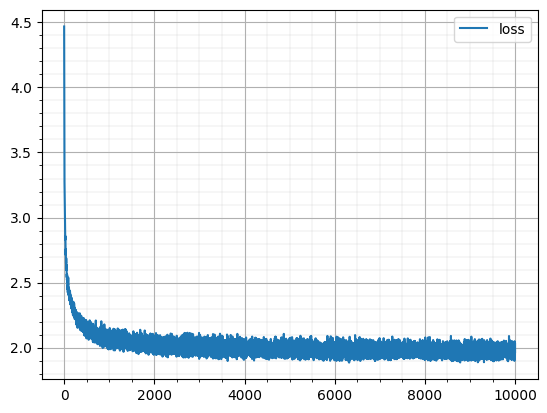

100%|██████████| 10000/10000 [20:09<00:00,  8.27it/s]


In [174]:
max_epoch = 10000

model.to(device)

history = []

for epoch in tqdm(range(max_epoch)):
    optimizer.zero_grad()
    x_batch = next(generate_chunk()).to(device)
    
    logits = rnn_loop(model, x_batch)
    
    target_logits = x_batch[:, 1:].flatten()
    
    pred_logits = logits[:, :-1, :].reshape(target_logits.numel(), -1)
    
    loss = loss_function(pred_logits, target_logits)
    
    loss.backward()
    
    optimizer.step()
    #scheduler.step(loss)
    
    history.append(loss.item())
    if (epoch + 1) % 100 == 0:
        clear_output(True)
        plt.plot(history, label=f"loss")
        plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5)
        plt.minorticks_on()
        plt.legend()
        plt.show()
        #torch.save(model.state_dict(), 'model.pth')
        #torch.save(optimizer.state_dict(), 'opt.pth')

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [175]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64, device=device)
    hidden_state = char_rnn.init_hidden_state(batch_size=1)
    
    for i in range(len(seed_phrase) - 1):
        hidden_state, _ = char_rnn(x_sequence[:, i], hidden_state)
    
    for _ in range(max_length - len(seed_phrase)):
        hidden_state, logits = char_rnn(x_sequence[:, -1], hidden_state)
        prob = F.softmax(logits / temperature, dim=-1).detach().cpu().numpy()[0]
        
        next_token = torch.tensor([[np.random.choice(num_tokens, p=prob)]], device=device)
        x_sequence = torch.cat([x_sequence, next_token], dim=1)
        
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

In [176]:
generate_sample(model, seed_phrase='абвг', device=device)

'<sos>абвгин издеря саве\nи порем батат она скоро послене мной,\nее нечтать вздох,\nмолец яснышну еня\nи голонке, что татьяноня…\nкарины;\nон наше хлася милых и языть:\nедравном всплучилсясь.\n\n\n\nliv\n\nлюбей,\nпорзар'

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [203]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=2))

<sos> мой дядя самых честных правилиеута:
язоршаваю, сралнет!.» лобннельет, на двы,:
n cetera
врепел тогда:
цаяуз:» у! почлеще; мщог кожурак.
то-сьгаще
престузомнибкииперси сла;
и охильце,
бо!ll
кмырим, жруд узгов
(не и
но,-то!,
обовилоv

схал.)



lii.
кивыу
и,,
явы! —-счовыма
тотел.

iто-зкльтай… тинь…,
xlиameы.

сгетнию дюжцось тон. что всё…, жчлемы вертвеличку,
явый еемустыцые двпернуц, нею к.-pr,
и шиетдию
он пуедах кнептышг, е;, кар.
к наобнето,
лсчко…
змалает, ктина, улыдиоша мыдивс,
перавлых,


### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [178]:
seed_phrase = ' мой дядя самых честных правил'

In [179]:
generated_phrases = [
    generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=1.
    ).replace('<sos>', '')
    for _ in range(10)
]

In [ ]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!